In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

seed = 67

In [2]:
def to_stochastic_form(M):
    A = np.zeros_like(M)
    M = M.T
    
    N = np.sum(M, axis = 0)
    N = np.transpose(N)

    A = M/N

    return A

Page Rank with mass redistribution

In [3]:
def mass_redistribution(A, d, eps, e):
    n, m = A.shape
    r = np.ones((n, 1))/n
    i = 0

    A = to_stochastic_form(A)

    ro = 1
    sigma = 1

    sigma_list = []

    while sigma > eps:
        r_new = d * (A @ r)
        ro = np.linalg.norm(r, 1) - np.linalg.norm(r_new, 1)
        r_new = r_new + ro * e

        sigma = np.linalg.norm(r_new - r, 1)
        sigma_list.append(sigma)

        i+=1

        r = r_new

    return r, i, sigma_list

Page Rank

In [4]:
def page_rank(A, d, e, eps):
    n, _ = A.shape

    r = np.ones((n, 1))/n
    one = np.ones((n, 1))

    A = to_stochastic_form(A)
    B = d * A + (1 - d) * e @ one.T

    for i in range(100):
        r_p = B @ r
        
        if np.linalg.norm(r_p - r, 1) < eps:
            return r_p, i

        r = r_p
    
    return r, 100

In [ ]:
def hanging_vertices(M):
    n, _ = M.shape

    c = M.sum(axis=1)
    c = np.where(c == 0, 1, 0).reshape(n, 1)

    e = np.ones((1, n))
    
    return M + c @ e

In [6]:
def cosine_sim(u, v):
    dot_product = np.dot(v.T, u)

    norm_real = np.linalg.norm(v)
    norm_power = np.linalg.norm(u)

    cosine_similarity = dot_product / (norm_real * norm_power)

    return (1.0 - np.abs(cosine_similarity)).item()

In [7]:
def top_n(v, n):
    return np.argsort(v.flatten())[-n:][::-1]

Loading data from Wiki Vote SNAP

In [8]:
G = nx.DiGraph()

with open('Wiki-Vote.txt') as f:
    for i, line in enumerate(f):
        if i < 4:
            continue
        p, q = line.strip().split()
        G.add_edge(p, q)

M = nx.to_numpy_array(G)

d parameters and number of iterations

In [16]:
def d_param_test(M, G, d_list):
    M = hanging_vertices(M)
    
    n, _ = M.shape
    e = np.ones((n, 1))
    e = e/n

    for d in d_list:
        v_mass_red, mass_it, _ = mass_redistribution(M, d, 1e-15, e)

        print(f"-------d----{d}----------------")
        print(f"Used {mass_it} iterations")
        print(f"Top 20 nodes {top_n(v_mass_red, 20)}")
        

In [17]:
d = [0.5, 0.6, 0.75, 0.85, 0.9]

d_param_test(M, G, d)

-------d----0.5----------------
Used 26 iterations
Top 20 nodes [ 326  409  686  711  656 1332  488  905 1141    3  177  884  666 1374
 1224 1261 1107   14    7 1229]
-------d----0.6----------------
Used 31 iterations
Top 20 nodes [ 326  409  711  686  656 1332  488  905 1141    3  666 1261  177  884
 1374 1107 1224 1229   14    7]
-------d----0.75----------------
Used 39 iterations
Top 20 nodes [ 326  409 1332  711  686  656  905 1141  488    3 1261  666 1229  247
 1107  841 1374  884  339  177]
-------d----0.85----------------
Used 46 iterations
Top 20 nodes [ 326  409 1332  711  905  686  656 1141 1261    3  666  488  247  841
 1229 1028  339 1107 1157    2]
-------d----0.9----------------
Used 50 iterations
Top 20 nodes [ 326 1332  409  711  905  656  686 1141 1261    3  666 1028  841  247
  339  488 1229 1157 1107 1225]


Conclusion: when d parameter increses number of iterations also grows up.

d parameter and changes in top-k

In [ ]:
def d_param_test(M, G, d_list):
    M = hanging_vertices(M)
    
    n, _ = M.shape
    e = np.ones((n, 1))
    e = e/n

    steps = []

    for d in d_list:
        v_mass_red, mass_it, _ = mass_redistribution(M, d, 1e-15, e)

        steps.append(set(top_n(v_mass_red, 50)))
    
    val = []
    for i in range(1, len(d_list)):
        val.append(len(steps[0] & steps[i]))
    
    plt.scatter(d_list[1:], val)
    plt.show()
        

[0.5, 0.6, 0.7, 0.75, 0.8, 0.9]


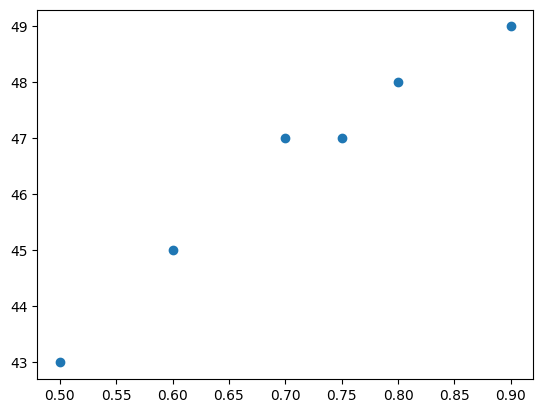

[43, 45, 47, 47, 48, 49]


In [37]:
d = [0.85, 0.5, 0.6, 0.7, 0.75, 0.80, 0.9]

d_param_test(M, G, d)

With increase of d, number of equals elements in intersetion of sets increases

E vector tests

In [ ]:
def e_param_test(M):
    outer_vert = np.where(M[326, :] != 0)[0]

    M = hanging_vertices(M)

    n, _ = M.shape

    #No prefernces
    e_1 = np.ones((n, 1))
    e_1 /= n

    e_con = np.zeros((n, 1))
    e_con[326] = 1
        
    v_mass_red, mass_it, _ = mass_redistribution(M, 0.75, 1e-15, e_con)
    v_1, mass_1, _ = mass_redistribution(M, 0.75, 1e-15, e_1)


    #################################
    #    Ranking when e = 1 / n     #
    #################################

    idx = np.array([i for i in range(n)])
    stacked = np.column_stack((idx, v_1.flatten()))
    sorted_data = stacked[stacked[:, 1].argsort()[::-1]]

    out = []

    for v in outer_vert:
        pos = np.where(sorted_data[:, 0] == v)[0][0]
        out.append(pos)

    print("Ranking when not concentrated")
    print(out)

    #################################
    #   Ranking when concentrated   #
    #################################

    idx = np.array([i for i in range(n)])
    stacked = np.column_stack((idx, v_mass_red.flatten()))
    sorted_data = stacked[stacked[:, 1].argsort()[::-1]]

    out = []

    for v in outer_vert:
        pos = np.where(sorted_data[:, 0] == v)[0][0]
        out.append(pos)

    print("Ranking after concentration")
    print(out)
        

In [12]:
e_param_test(M)

Ranking when not concentrated
[1, 109, 79, 322, 71, 97, 125, 358, 116, 165, 254, 87, 281, 290, 115]
Ranking after concentration
[1, 7, 6, 15, 4, 2, 5, 13, 8, 10, 12, 3, 14, 11, 9]


It is evident that when the teleportation probability is concentrated on a single vertex, its neighbors also benefit, resulting in a higher position in the ranking.

Visualizations

Theoretical sigma

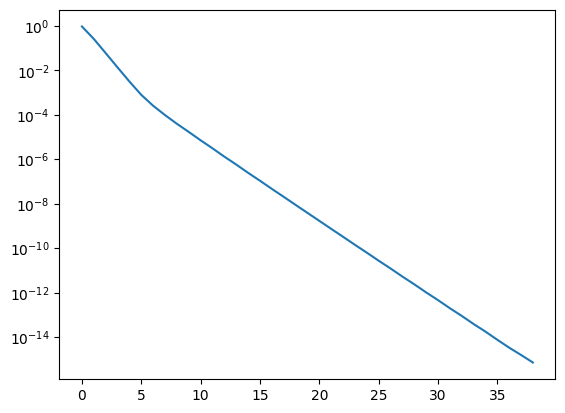

-0.2876820724517809
-0.8215474849803911


In [13]:
M = hanging_vertices(M)
    
n, _ = M.shape
e = np.ones((n, 1))
e = e/n

_, _, sigma = mass_redistribution(M, 0.75, 1e-15, e)

its = len(sigma)
t = np.arange(0, its, 1)

theory = d

plt.semilogy(t, sigma)
plt.show()

print(np.log(0.75))

delta = np.array(sigma)

i1 = 30
i2 = 35

a = (np.log(delta[i2]) - np.log(delta[i1])) / (i2 - i1)

print(a)


Histogram

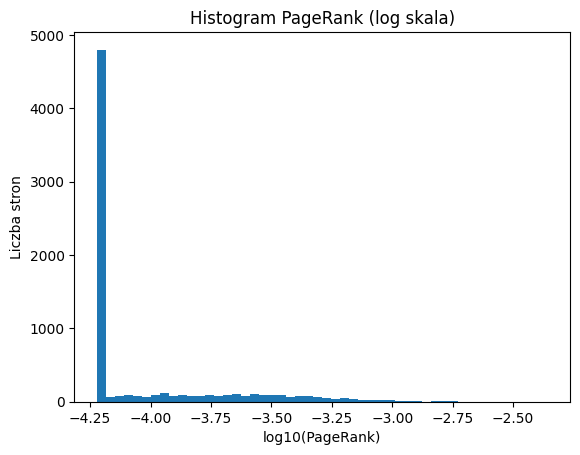

In [14]:
M = hanging_vertices(M)
    
n, _ = M.shape
e = np.ones((n, 1))
e = e/n

vec, _, sigma = mass_redistribution(M, 0.75, 1e-15, e)

vec = vec[vec > 0]

log_pr = np.log10(vec)

plt.hist(log_pr, bins=50)
plt.xlabel("log10(PageRank)")
plt.ylabel("Liczba stron")
plt.title("Histogram PageRank (log skala)")
plt.show()

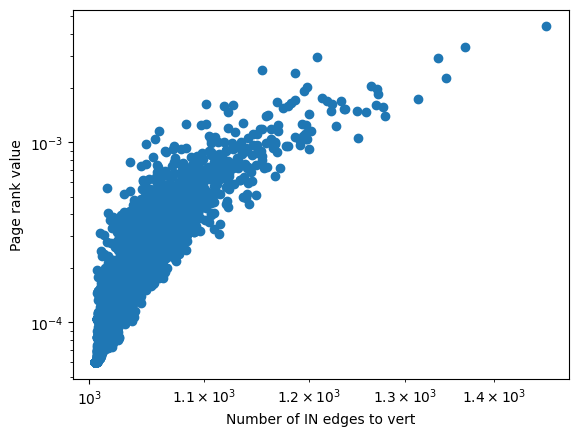

In [39]:
in_degress = np.sum(M, axis = 0)
M = hanging_vertices(M)
    
n, _ = M.shape
e = np.ones((n, 1))
e = e/n

vec, _, sigma = mass_redistribution(M, 0.75, 1e-15, e)

plt.scatter(in_degress, vec)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Number of IN edges to vert")
plt.ylabel("Page rank value")
plt.show()